**HOML Chapter 14 – Pretrained Models for Transfer Learning**

This notebook demonstrates the use of pretrained models for transfer learning.

It uses a pretrained Xception model trained on ImageNet to classify 3670 pictures of flowers in 5 classes.

See also HOML page 518.

# Setup

This project requires Python 3.7 or above:

In [14]:
import sys

assert sys.version_info >= (3, 7)

In [15]:
import numpy as np
import pandas as pd

It also requires Scikit-Learn ≥ 1.0.1:

In [16]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [17]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [18]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [19]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


# Pretrained Models for Transfer Learning

In [20]:
# import the flowers dataset from TensorFlow Datasets

import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

C:\Users\daank\PycharmProjects\data-science-homework-2025\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]
Generating train examples...: 0 examples [00:00, ? examples/s]
Generating train examples...: 2317 examples [00:01, 2315.88 examples/s]
                                                                       
Shuffling C:\Users\daank\tensorflow_datasets\tf_flowers\incomplete.0BHA9N_3.0.1\tf_flowers-train.tfrecord*...:   0%|          | 0/3670 [00:00<?, ? examples/s]
                                                                                                                                                              

Dataset tf_flowers downloaded and prepared to C:\Users\daank\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.


In [21]:
# lets see how many flower pictures there are in the dataset

dataset_size

3670

In [22]:
# what are class names of the dataset

class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [23]:
# how many classes do we have

n_classes

5

In [24]:
# lets call tfds.load again and split up the data, first 10% for the test set, next 15% for validation and the remaining 75% for training

test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

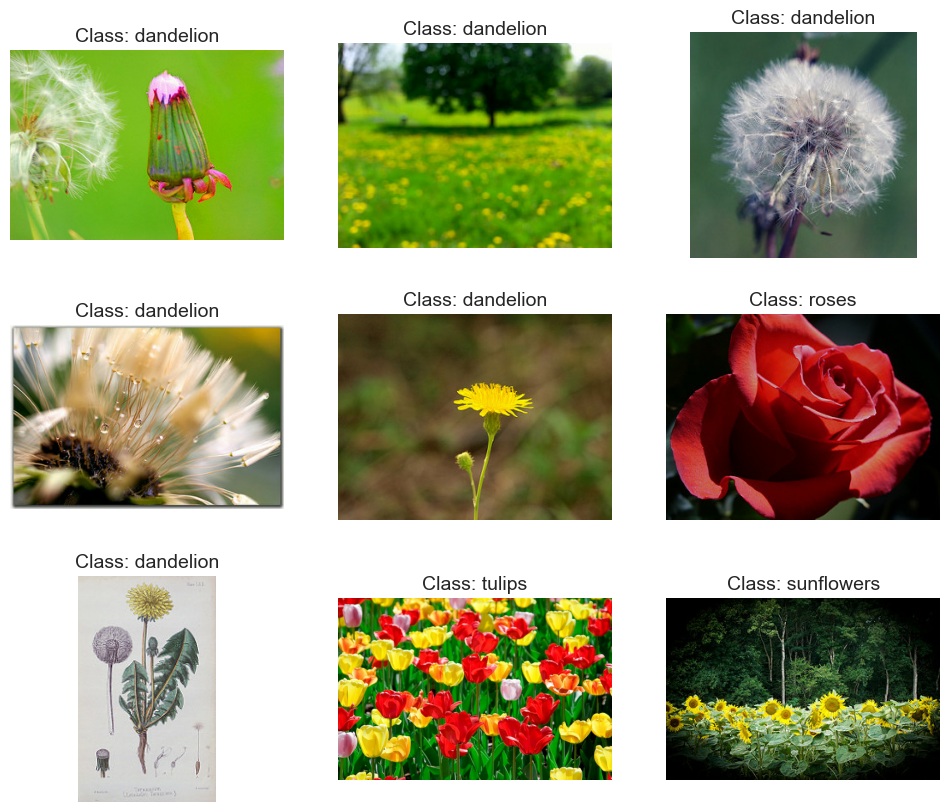

In [25]:
# extra code – displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

All three datasets contain individual images. We need to batch them, but for this we first need to ensure they all have the same size, or else batching will not work. We can use a `Resizing` layer for this. We must also call the `tf.keras.applications.xception.preprocess_input()` function to preprocess the images appropriately for the Xception model. We will also add shuffling and prefetching to the training dataset.

In [26]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

Now each batch contains 32 images, all of them 224 x 224 pixels, with pixel values ranging from -1 to 1.

Let's take a look again at the first 9 images from the validation set: they're all 224x224 now, with values ranging from -1 to 1:

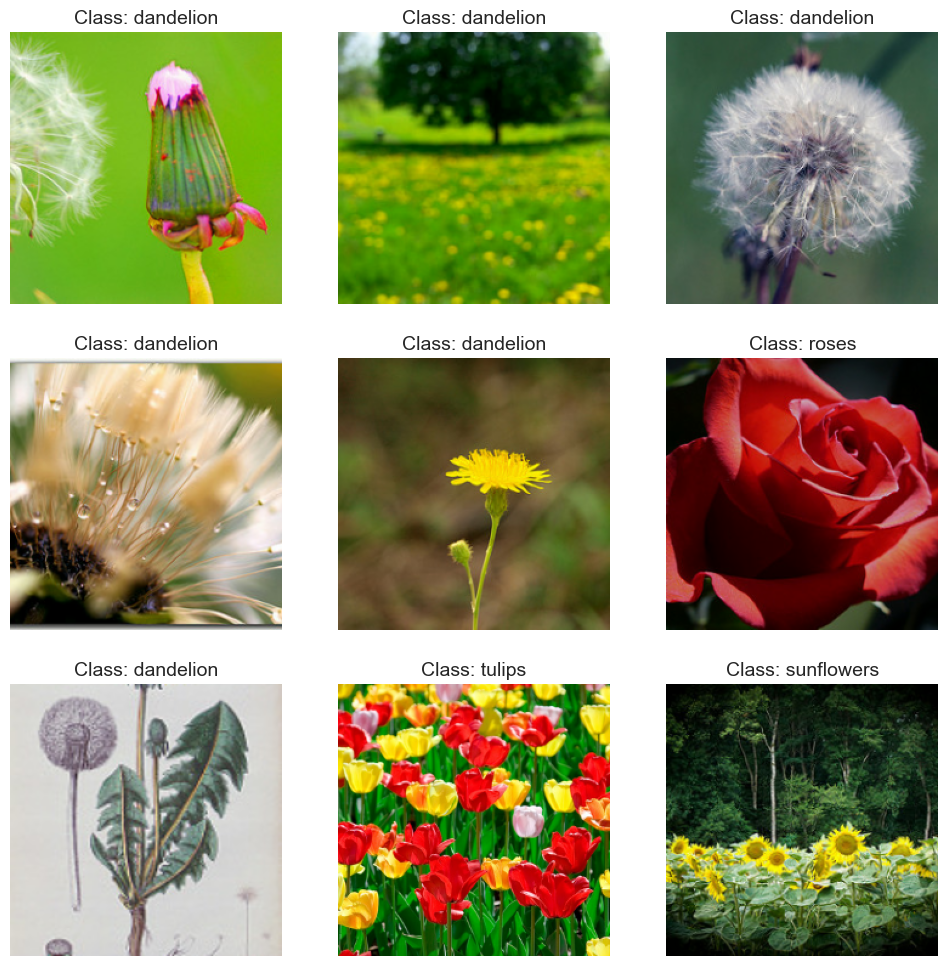

In [27]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

In [28]:
# this data augmentation model will be embedded in the final model.
# during training it will randomly flip the images horizontally, rotate them a little bit, and tweak the contrast

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the following cell multiple times to see different random data augmentations:

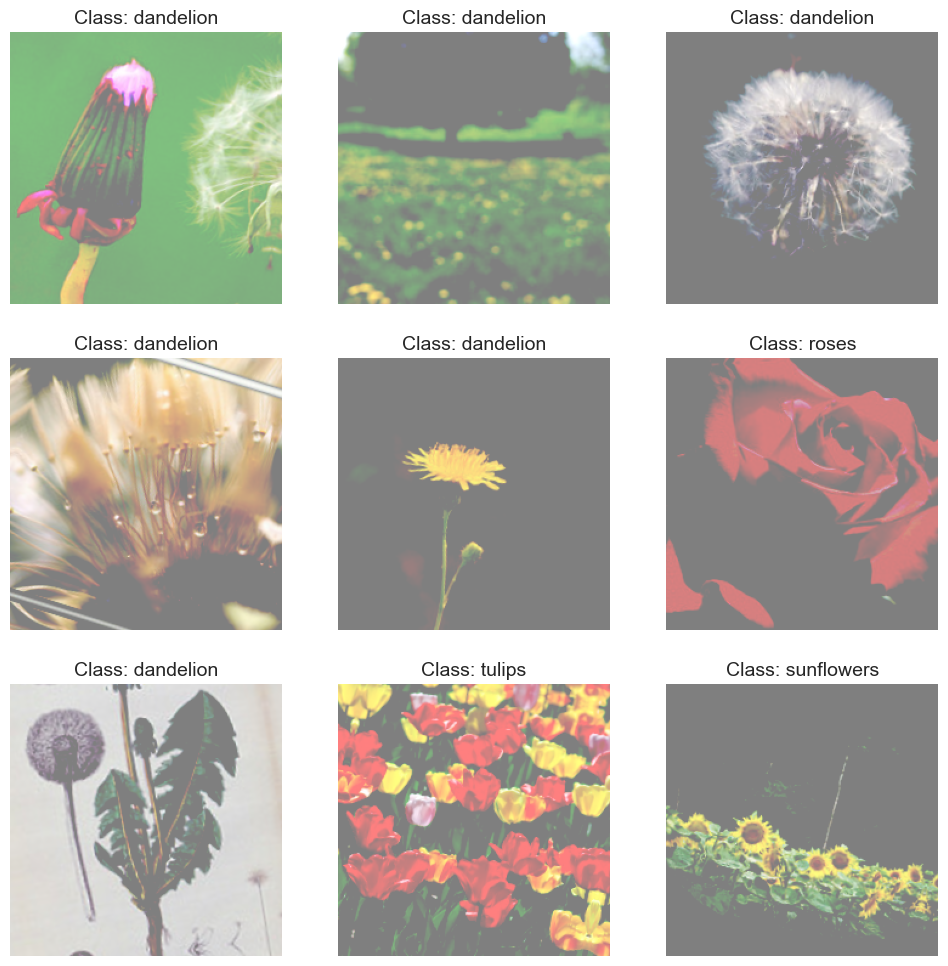

In [29]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Now let's load the pretrained model, without its top layers (global average pooling + dense output layers), and replace them with our own, for the flower classification task:

In [30]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [31]:
# freeze the weigths of the pretrained layers (base_model) at the beginning of training

for layer in base_model.layers:
    layer.trainable = False

Let's train the model for a few epochs, while keeping the base model weights fixed:

In [32]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
21/86 ━━━━━━━━━━━━━━━━━━━━ 1:27 1s/step - accuracy: 0.5120 - loss: 1.2030

KeyboardInterrupt: 

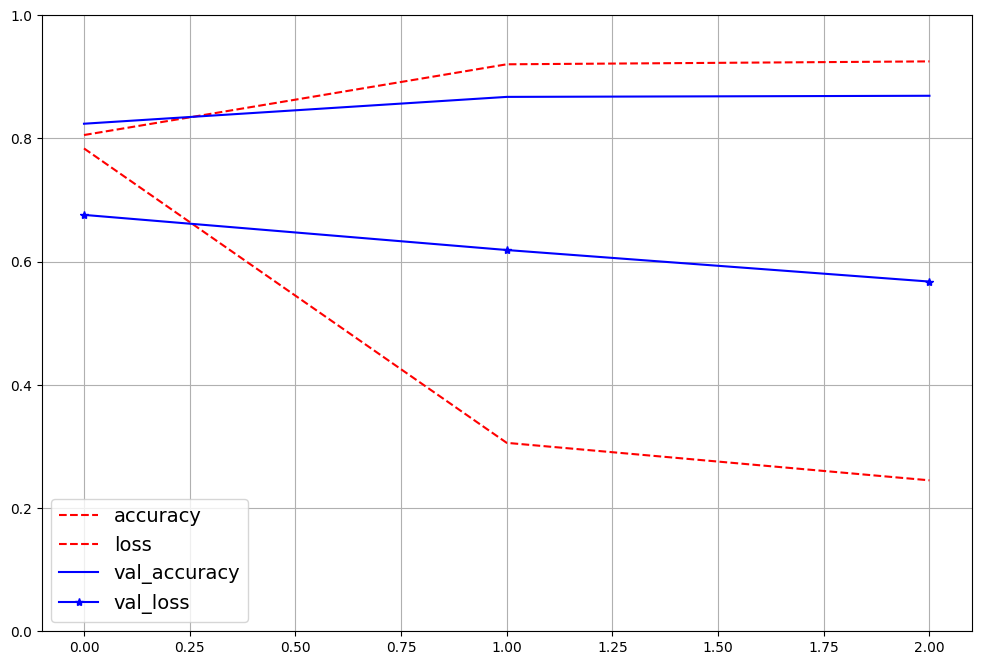

In [20]:
# Lets check if the validation accuracy reaches more than 80%
# If so, we can start to unfreeze some of the base models top layers and train again

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [21]:
# lets make a list of the base model layer names

for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Now that the weights of our new top layers are not too bad, we can make the top part of the base model trainable again, and continue training, but with a lower learning rate:

In [22]:
# unfreeze starting from layer 56 of the base model

for layer in base_model.layers[56:]:
    layer.trainable = True

# lower the learning rate

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

# build the model

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# train the model with 10 epochs

history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 53s 377ms/step - accuracy: 0.8710 - loss: 0.3742 - val_accuracy: 0.8784 - val_loss: 0.6253
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.9827 - loss: 0.0547 - val_accuracy: 0.8947 - val_loss: 0.3550
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.9963 - loss: 0.0175 - val_accuracy: 0.9056 - val_loss: 0.3118
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.9986 - loss: 0.0071 - val_accuracy: 0.9038 - val_loss: 0.3108
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.9990 - loss: 0.0037 - val_accuracy: 0.9111 - val_loss: 0.3277
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9111 - val_loss: 0.3525
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 292ms/step - accuracy: 0.9988 - loss: 0.0054 - val_accuracy: 0.9056 - val_loss: 0.3488
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 292ms/step - accuracy: 0.9997 - loss: 0.0025 - val_accu

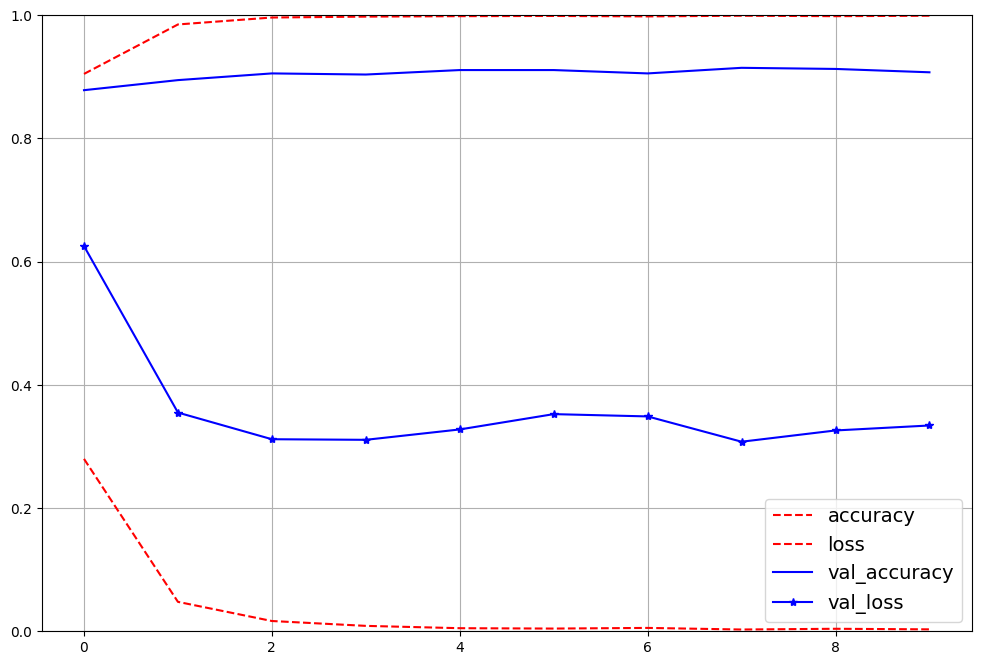

In [23]:
# Lets see if the validation accuracy has improved after unfreezing top layers of the base model

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [24]:
# lets unfreeze some more
# unfreeze starting from layer 36 of the base model

for layer in base_model.layers[36:]:
    layer.trainable = True

# lower the learning rate

optimizer = tf.keras.optimizers.SGD(learning_rate=0.005, momentum=0.9)

# build the model

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# train the model with 10 epochs

history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 418ms/step - accuracy: 0.9938 - loss: 0.0107 - val_accuracy: 0.8966 - val_loss: 0.3384
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 335ms/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 0.9129 - val_loss: 0.3230
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9147 - val_loss: 0.3173
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - accuracy: 0.9977 - loss: 0.0032 - val_accuracy: 0.9165 - val_loss: 0.3224
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 329ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9111 - val_loss: 0.3300
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 325ms/step - accuracy: 0.9997 - loss: 0.0026 - val_accuracy: 0.9220 - val_loss: 0.3302
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.9987 - loss: 0.0022 - val_accuracy: 0.9256 - val_loss: 0.3298
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 327ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accu

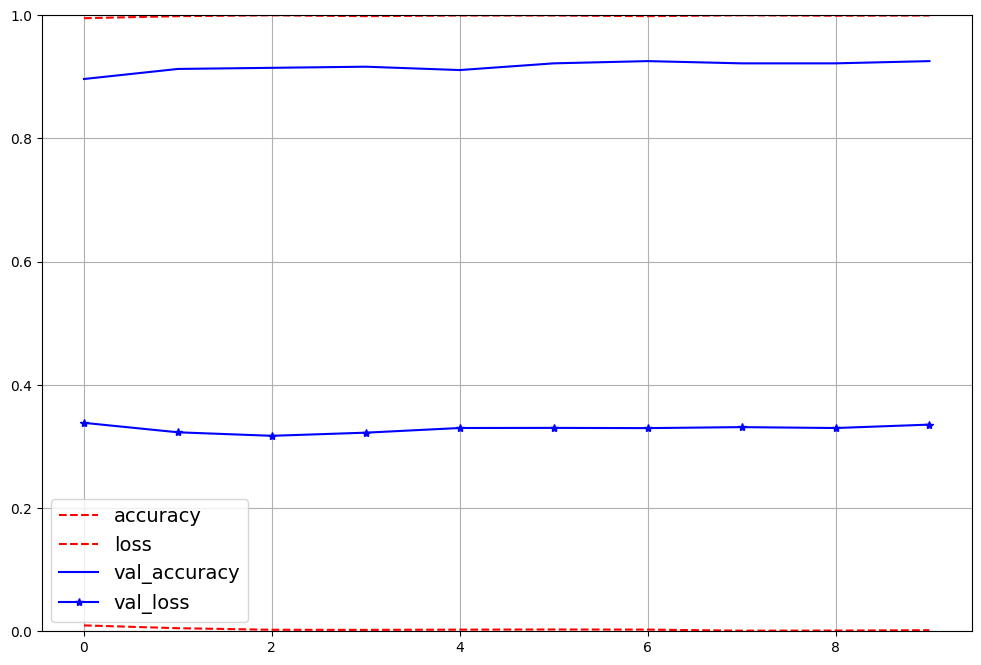

In [25]:
# Lets see if the validation accuracy has improved after unfreezing top layers of the base model

pd.DataFrame(history.history).plot(figsize=(12, 8), style=['r--','r--','b-','b-*'])
plt.grid(True)
plt.gca().set_ylim(0, 1) #set y-axis limits
plt.show()

In [26]:
# Evaluate on the test set

model.evaluate(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9370 - loss: 0.2221


[0.233104407787323, 0.9373297095298767]